In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 5G_QoS_Dataset.csv to 5G_QoS_Dataset (1).csv


In [ ]:
import pandas as pd

gen = pd.read_csv("5G_QoS_Dataset.csv")

# Average metrics per traffic type
trend = gen.groupby("Traffic_Type")[["Delay_ms","Throughput_Mbps","SINR_dB"]].mean()

print(trend)

               Delay_ms  Throughput_Mbps    SINR_dB
Traffic_Type                                       
URLLC          2.994360        85.459700  25.003739
eMBB          35.817932       150.653918  19.994957
mMTC          54.538996        11.972889   9.965159


/tmp/ipykernel_12448/1850906117.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


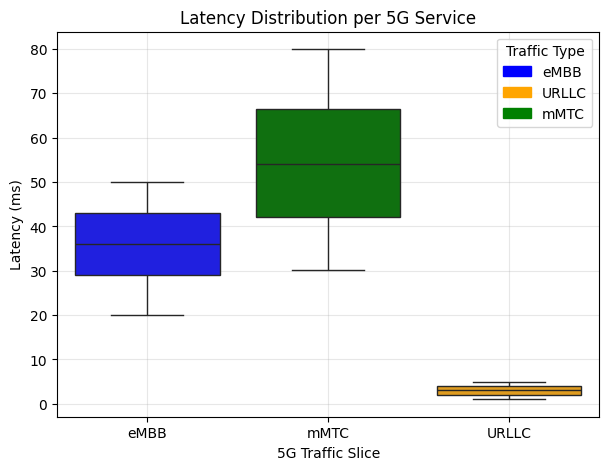

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.figure(figsize=(7,5))

palette = {"eMBB": "blue", "URLLC": "orange", "mMTC": "green"}

sns.boxplot(
    x="Traffic_Type",
    y="Delay_ms",
    data=gen,
    palette=palette
)

# Create custom legend
legend_handles = [
    mpatches.Patch(color=color, label=label)
    for label, color in palette.items()
]

plt.legend(handles=legend_handles, title="Traffic Type")

plt.xlabel("5G Traffic Slice")
plt.ylabel("Latency (ms)")
plt.title("Latency Distribution per 5G Service")

plt.grid(alpha=0.3)
plt.show()

/tmp/ipykernel_12448/79696748.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


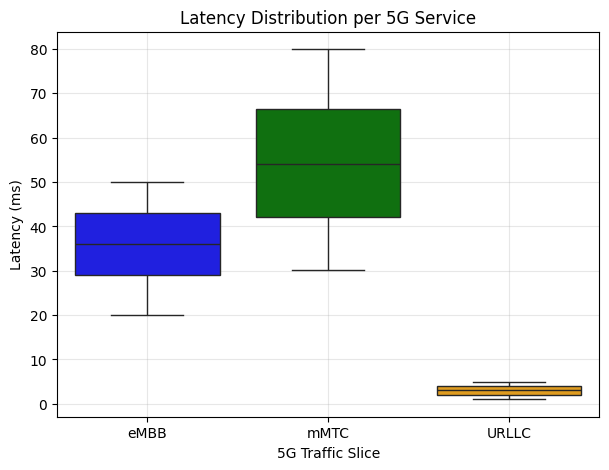

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.boxplot(
    x="Traffic_Type",
    y="Delay_ms",
    data=gen,
    palette={"eMBB": "blue", "URLLC": "orange", "mMTC": "green"}
)

plt.xlabel("5G Traffic Slice")
plt.ylabel("Latency (ms)")
plt.title("Latency Distribution per 5G Service")

plt.grid(alpha=0.3)
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Quality of Service 5G.csv to Quality of Service 5G (1).csv


In [ ]:
pub = pd.read_csv("Quality of Service 5G.csv")

pub["Allocated_Bandwidth"] = pub["Allocated_Bandwidth"].str.replace(" Mbps","")
pub["Allocated_Bandwidth"] = pub["Allocated_Bandwidth"].str.replace(" Kbps","")
pub["Allocated_Bandwidth"] = pub["Allocated_Bandwidth"].astype(float)

In [ ]:
import pandas as pd

pub = pd.read_csv("Quality of Service 5G.csv")

# remove " ms"
pub["Latency"] = pub["Latency"].str.replace(" ms", "", regex=False)

# convert to numeric
pub["Latency"] = pd.to_numeric(pub["Latency"])

In [ ]:
print("Generated Delay Mean:", gen["Delay_ms"].mean())
print("Public Latency Mean:", pub["Latency"].mean())

Generated Delay Mean: 30.531466070319034
Public Latency Mean: 33.825


In [ ]:
from scipy.stats import ks_2samp

ks_test = ks_2samp(gen["Delay_ms"], pub["Latency"])

print("KS statistic:", ks_test.statistic)
print("p-value:", ks_test.pvalue)

KS statistic: 0.3155
p-value: 1.230812745142123e-25


In [ ]:
corr = gen[["SINR_dB","Throughput_Mbps","Delay_ms","RB_Allocation"]].corr()

print(corr)

                  SINR_dB  Throughput_Mbps  Delay_ms  RB_Allocation
SINR_dB          1.000000         0.628366 -0.776730       0.420198
Throughput_Mbps  0.628366         1.000000 -0.307375       0.953241
Delay_ms        -0.776730        -0.307375  1.000000      -0.146223
RB_Allocation    0.420198         0.953241 -0.146223       1.000000


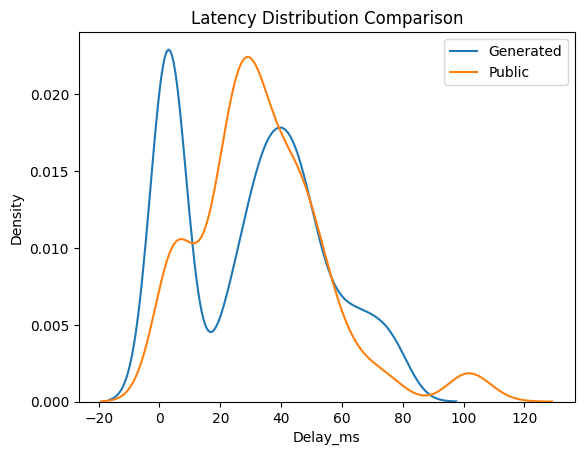

In [ ]:
sns.kdeplot(gen["Delay_ms"], label="Generated")
sns.kdeplot(pub["Latency"], label="Public")

plt.legend()
plt.title("Latency Distribution Comparison")
plt.show()

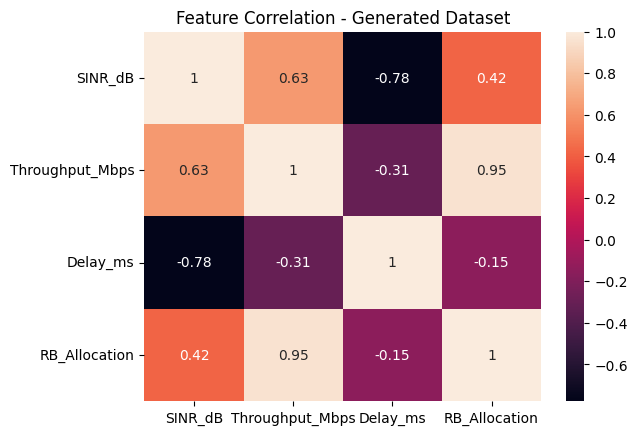

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr, annot=True)
plt.title("Feature Correlation - Generated Dataset")
plt.show()

In [ ]:
pub["Signal_Strength"] = pub["Signal_Strength"].str.replace(" dBm","").astype(float)

In [ ]:
pub_corr = pub[["Signal_Strength","Latency"]].corr()

print(pub_corr)

                 Signal_Strength   Latency
Signal_Strength         1.000000 -0.392676
Latency                -0.392676  1.000000


In [ ]:
pub = pub.rename(columns={
    "Latency":"Delay_ms",
    "Signal_Strength":"SINR_dB",
    "Allocated_Bandwidth":"Throughput_Mbps"
})

In [ ]:
features = ["SINR_dB","Throughput_Mbps"]

X_gen = gen[features]
y_gen = gen["Delay_ms"]

X_pub = pub[features]
y_pub = pub["Delay_ms"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_gen, y_gen, test_size=0.2, random_state=42
)

In [ ]:
print(type(X_train))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
import numpy as np
X_train_lstm = np.array(X_train).reshape((len(X_train),1,X_train.shape[1]))
X_test_lstm  = np.array(X_test).reshape((len(X_test),1,X_test.shape[1]))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()

model.add(LSTM(64, input_shape=(1,X_train.shape[1])))
model.add(Dense(32, activation="relu"))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")

model.fit(X_train_lstm, y_train, epochs=20, batch_size=32)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1431.7758
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1317.2684
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1084.6168
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 772.2620
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 589.7492
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 515.1178
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 467.8496
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 435.7802
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 409.1339
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 386.4412
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 369.2195
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 351.4744
Epoch 13/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 337.5297
Epoch 14/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 327.9021
Epoch 15/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 320.46

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

pred = model.predict(X_test_lstm)

rmse = np.sqrt(mean_squared_error(y_test, pred))

print("LSTM RMSE:", rmse)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
LSTM RMSE: 17.33183699267696


In [ ]:
import pandas as pd

pub = pd.read_csv("Quality of Service 5G.csv")

# Extract numbers from columns with units
pub["Latency"] = pub["Latency"].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

pub["Signal_Strength"] = pub["Signal_Strength"].astype(str).str.extract(r'(-?\d+\.?\d*)').astype(float)

pub["Allocated_Bandwidth"] = pub["Allocated_Bandwidth"].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

pub["Required_Bandwidth"] = pub["Required_Bandwidth"].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

In [ ]:


features = [
    "Signal_Strength",
    "Allocated_Bandwidth",
    "Required_Bandwidth"
]

X_pub = pub[features]
y_pub = pub["Latency"]
X_pub = X_pub.fillna(X_pub.mean())
print(X_pub.dtypes)

Signal_Strength        float64
Allocated_Bandwidth    float64
Required_Bandwidth     float64
dtype: object


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_pub = scaler.fit_transform(X_pub)

In [ ]:
import numpy as np

X_pub_lstm = X_pub.reshape((X_pub.shape[0],1,X_pub.shape[1]))

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_pub = scaler.fit_transform(X_pub)

In [ ]:
from sklearn.model_selection import train_test_split

X_train_pub, X_test_pub, y_train_pub, y_test_pub = train_test_split(
    X_pub, y_pub, test_size=0.2, random_state=42
)

In [ ]:
print(X_train_pub.shape)
print(X_test_pub.shape)

(320, 3)
(80, 3)


In [ ]:
import numpy as np

X_train_pub = X_train_pub.reshape((X_train_pub.shape[0], 1, X_train_pub.shape[1]))
X_test_pub  = X_test_pub.reshape((X_test_pub.shape[0], 1, X_test_pub.shape[1]))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model_pub = Sequential()

model_pub.add(LSTM(64, input_shape=(1, X_train_pub.shape[2])))
model_pub.add(Dense(32, activation="relu"))
model_pub.add(Dense(1))

model_pub.compile(
    optimizer="adam",
    loss="mse"
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history = model_pub.fit(
    X_train_pub,
    y_train_pub,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 1637.4482 - val_loss: 1651.9424
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1632.8108 - val_loss: 1646.7198
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1626.7749 - val_loss: 1640.1367
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1619.2081 - val_loss: 1631.6912
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1609.6892 - val_loss: 1620.7584
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1596.8802 - val_loss: 1606.7437
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1580.5040 - val_loss: 1588.8135
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1560.4336 - val_loss: 1565.7913
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1533.9594 - val_loss: 1537.3215
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1501.8284 - val_loss: 1502.2866
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1462.0549 - val_loss: 1460.0576
Epoch 12/20
8/8 ━━━

In [ ]:
pred_pub = model_pub.predict(X_test_pub)

print(pred_pub[:10])

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
[[17.563358]
 [25.135733]
 [19.471407]
 [16.824171]
 [17.833841]
 [16.652815]
 [17.37177 ]
 [16.78847 ]
 [17.786535]
 [31.985424]]


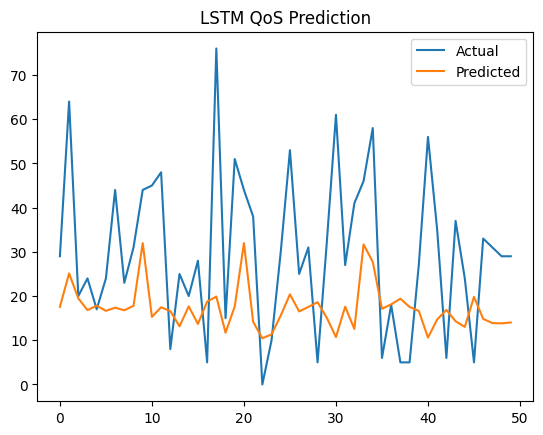

In [ ]:
import matplotlib.pyplot as plt

plt.plot(y_test_pub.values[:50], label="Actual")
plt.plot(pred_pub[:50], label="Predicted")

plt.legend()
plt.title("LSTM QoS Prediction")
plt.show()

In [ ]:
features = ["SINR_dB","Throughput_Mbps","RB_Allocation"]

X_gen = gen[features]
y_gen = gen["Delay_ms"]

X_pub = pub[["Signal_Strength","Allocated_Bandwidth","Required_Bandwidth"]]
y_pub = pub["Latency"]

In [ ]:
features_gen = ["SINR_dB", "Throughput_Mbps", "RB_Allocation"]

X_gen = gen[features_gen]
y_gen = gen["Delay_ms"]

In [ ]:
X_gen = X_gen.apply(pd.to_numeric, errors="coerce")
X_gen = X_gen.fillna(X_gen.mean())

In [ ]:
from sklearn.model_selection import train_test_split

X_train_gen, X_test_gen, y_train_gen, y_test_gen = train_test_split(
    X_gen, y_gen, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

rf = RandomForestRegressor(n_estimators=100)

rf.fit(X_train_gen, y_train_gen)

pred_gen_rf = rf.predict(X_test_gen)

rmse_gen_rf = np.sqrt(mean_squared_error(y_test_gen, pred_gen_rf))

print("Generated Dataset RF RMSE:", rmse_gen_rf)

Generated Dataset RF RMSE: 11.072614779130525


In [ ]:
features_pub = ["Signal_Strength", "Allocated_Bandwidth", "Required_Bandwidth"]

X_pub = pub[features_pub]
y_pub = pub["Latency"]

X_pub = X_pub.apply(pd.to_numeric, errors="coerce")
X_pub = X_pub.fillna(X_pub.mean())

X_train_pub, X_test_pub, y_train_pub, y_test_pub = train_test_split(
    X_pub, y_pub, test_size=0.2, random_state=42
)

In [ ]:
pub_renamed = pub.rename(columns={
    "Signal_Strength": "SINR_dB",
    "Allocated_Bandwidth": "Throughput_Mbps",
    "Required_Bandwidth": "RB_Allocation"
})

In [ ]:
features = ["SINR_dB", "Throughput_Mbps", "RB_Allocation"]

X_pub = pub_renamed[features]
y_pub = pub_renamed["Latency"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train_pub, X_test_pub, y_train_pub, y_test_pub = train_test_split(
    X_pub, y_pub, test_size=0.2, random_state=42
)

In [ ]:
pred_pub_rf = rf.predict(X_test_pub)

rmse_pub_rf = np.sqrt(mean_squared_error(y_test_pub, pred_pub_rf))

print("Public Dataset RF RMSE:", rmse_pub_rf)

Public Dataset RF RMSE: 22.668202684345626


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Generated RMSE": [rmse_gen_rf],
    "Public RMSE": [rmse_pub_rf]
})

print(results)

           Model  Generated RMSE  Public RMSE
0  Random Forest       11.072615    22.668203


In [ ]:
from sklearn.metrics import mean_absolute_error
mae_gen_rf = mean_absolute_error(y_test_gen, pred_gen_rf)

print("Generated Dataset RF MAE:", mae_gen_rf)

mae_pub_rf = mean_absolute_error(y_test_pub, pred_pub_rf)

print("Public Dataset RF MAE:", mae_pub_rf)

Generated Dataset RF MAE: 7.557442931021387
Public Dataset RF MAE: 19.654100937594656


In [ ]:
import pandas as pd

rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Generated RMSE": [rmse_gen_rf],
    "Generated MAE": [mae_gen_rf],
    "Public RMSE": [rmse_pub_rf],
    "Public MAE": [mae_pub_rf]
})

print(rf_results)

           Model  Generated RMSE  Generated MAE  Public RMSE  Public MAE
0  Random Forest       11.072615       7.557443    22.668203   19.654101


In [ ]:
import numpy as np

# reshape generated dataset
X_train_gen_lstm = X_train_gen.values.reshape((X_train_gen.shape[0],1,X_train_gen.shape[1]))
X_test_gen_lstm  = X_test_gen.values.reshape((X_test_gen.shape[0],1,X_test_gen.shape[1]))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model_gen = Sequential()

model_gen.add(LSTM(64, input_shape=(1, X_train_gen.shape[1])))
model_gen.add(Dense(32, activation="relu"))
model_gen.add(Dense(1))

model_gen.compile(optimizer="adam", loss="mse")

model_gen.fit(X_train_gen_lstm, y_train_gen, epochs=20, batch_size=32, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

pred_gen_lstm = model_gen.predict(X_test_gen_lstm)

rmse_gen_lstm = np.sqrt(mean_squared_error(y_test_gen, pred_gen_lstm))
mae_gen_lstm  = mean_absolute_error(y_test_gen, pred_gen_lstm)

print("LSTM Generated RMSE:", rmse_gen_lstm)
print("LSTM Generated MAE:", mae_gen_lstm)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
LSTM Generated RMSE: 13.736922440958224
LSTM Generated MAE: 12.18082463235073


In [ ]:
# reshape public dataset
X_train_pub_lstm = X_train_pub.values.reshape((X_train_pub.shape[0],1,X_train_pub.shape[1]))
X_test_pub_lstm  = X_test_pub.values.reshape((X_test_pub.shape[0],1,X_test_pub.shape[1]))

In [ ]:
pred_pub_lstm = model_pub.predict(X_test_pub_lstm)

rmse_pub_lstm = np.sqrt(mean_squared_error(y_test_pub, pred_pub_lstm))
mae_pub_lstm  = mean_absolute_error(y_test_pub, pred_pub_lstm)

print("LSTM Public RMSE:", rmse_pub_lstm)
print("LSTM Public MAE:", mae_pub_lstm)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
LSTM Public RMSE: 35.650757579166175
LSTM Public MAE: 30.31401236243546


In [ ]:
import pandas as pd

final_results = pd.DataFrame({
    "Model": ["LSTM", "Random Forest"],

    "Generated RMSE": [rmse_gen_lstm, rmse_gen_rf],
    "Generated MAE":  [mae_gen_lstm, mae_gen_rf],

    "Public RMSE": [rmse_pub_lstm, rmse_pub_rf],
    "Public MAE":  [mae_pub_lstm, mae_pub_rf]
})

print(final_results)

           Model  Generated RMSE  Generated MAE  Public RMSE  Public MAE
0           LSTM       13.736922      12.180825    35.650758   30.314012
1  Random Forest       11.072615       7.557443    22.668203   19.654101
